In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd

In [6]:
# --- Data Loading (Unchanged) ---
url = 'https://comet.nefsc.noaa.gov/erddap/griddap/noaa_psl_2d74_d418_a6fb'
ds = xr.open_dataset(url)
ds1 = ds

# --- Longitude Re-indexing (Unchanged) ---
# Convert 0-360 longitude to -180 to 180
ds2 = ds1.assign_coords(longitude = ((ds1.longitude + 180) % 360) - 180)
ds2 = ds2.sortby('longitude') 
ds2

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 531, latitude: 720, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-09-01 1981-10-01 ... 2025-11-01
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    sst        (time, latitude, longitude) float32 2GB ...
Attributes: (12/35)
    cdm_data_type:              Grid
    comment:                    Reynolds, et al.(2007) Daily High-Resolution-...
    Conventions:                CF-1.10, COARDS, ACDD-1.3
    creator_name:               NOAA/National Centers for Environmental Infor...
    creator_type:               group
    creator_url:                https://www.noaa.gov/
    ...                         ...
    testOutOfDate:              now-114days
    time_coverage_end:          2025-11-01T00:00:00Z
    time_coverage_start:        1981-09-01T00:00:00Z
    title:                      Satellite Sea Surface Tempearture | NOAA/NCEI...
    version:                    Version 2.1
    Westernmost_Easting:        0.125

In [1]:
colormap = 'RdBu_r'

date_range = ("1982-01-01", "2024-12-01")

lat_min = -10
lat_max = 20
lon_min = -30
lon_max = 15

#create smaller box for the local region
lat_min_sm = 12.6
lat_max_sm = 16.6
lon_min_sm = -19.6
lon_max_sm = -15.6

#input deployment locations
#site 1 deployment 1
deployment0101_lat = 14.616
deployment0101_lon = -17.631

#site 1, deployment 2
deployment0102_lat =14.615
deployment0102_lon =-17.630

#site 1, deployment 3
deployment0103_lat = 14.618
deployment0103_lon = -17.628

#site 1, deployment 4
deployment0104_lat = 14.618
deployment0104_lon = -17.628

#site 2, deployments 1 & 2
deployment020102_lat = 14.742
deployment020102_lon = -17.636

#region around recorders
rec_lat_min = 12 
rec_lat_max = 17
rec_lon_min = -20
rec_lon_max = -12

#CVI coords
CVI_lat_min = 14
CVI_lat_max = 18
CVI_lon_min = -27
CVI_lon_max = -21

#GoG Gulf of Guinea
GoG_lat_min = -10
GoG_lat_max = 7
GoG_lon_min = 6
GoG_lon_max = 15

In [11]:
LATITUDE_MIN = lat_min
LATITUDE_MAX = lat_max
LONGITUDE_MIN = lon_min
LONGITUDE_MAX = lon_max

ds_bigbox = ds2['sst'].sel(latitude=slice(LATITUDE_MIN, LATITUDE_MAX), 
                longitude=slice(LONGITUDE_MIN, LONGITUDE_MAX))
ds_bigbox

<xarray.DataArray 'sst' (time: 531, latitude: 120, longitude: 180)> Size: 46MB
[11469600 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-09-01 1981-10-01 ... 2025-11-01
  * latitude   (latitude) float32 480B -9.875 -9.625 -9.375 ... 19.62 19.88
  * longitude  (longitude) float32 720B -29.88 -29.62 -29.38 ... 14.62 14.88
Attributes: (12/13)
    actual_range:     [-1.8  32.14]
    colorBarMaximum:  32.0
    colorBarMinimum:  0.0
    ioos_category:    Temperature
    level_desc:       Surface
    long_name:        Monthly Mean of Sea Surface Temperature
    ...               ...
    precision:        2.0
    standard_name:    sea_surface_temperature
    statistic:        Monthly Mean
    units:            degree_C
    valid_range:      [-3. 45.]
    var_desc:         Sea Surface Temperature

In [12]:
ds_bigbox

<xarray.DataArray 'sst' (time: 531, latitude: 120, longitude: 180)> Size: 46MB
[11469600 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-09-01 1981-10-01 ... 2025-11-01
  * latitude   (latitude) float32 480B -9.875 -9.625 -9.375 ... 19.62 19.88
  * longitude  (longitude) float32 720B -29.88 -29.62 -29.38 ... 14.62 14.88
Attributes: (12/13)
    actual_range:     [-1.8  32.14]
    colorBarMaximum:  32.0
    colorBarMinimum:  0.0
    ioos_category:    Temperature
    level_desc:       Surface
    long_name:        Monthly Mean of Sea Surface Temperature
    ...               ...
    precision:        2.0
    standard_name:    sea_surface_temperature
    statistic:        Monthly Mean
    units:            degree_C
    valid_range:      [-3. 45.]
    var_desc:         Sea Surface Temperature

In [13]:
# --- 2. Setup Multi-Panel Figure ---
# Define the 5 time slices to plot (e.g., the first 5 months)
time_slices = ds_bigbox['time'][200:205] 
N_PLOTS = len(time_slices)
time_slices

<xarray.DataArray 'time' (time: 5)> Size: 40B
array(['1998-05-01T00:00:00.000000000', '1998-06-01T00:00:00.000000000',
       '1998-07-01T00:00:00.000000000', '1998-08-01T00:00:00.000000000',
       '1998-09-01T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 40B 1998-05-01 1998-06-01 ... 1998-09-01
Attributes:
    _CoordinateAxisType:  Time
    actual_range:         [3.6815040e+08 1.7619552e+09]
    avg_period:           0000-01-00 00:00:00
    axis:                 T
    delta_t:              0000-01-00 00:00:00
    ioos_category:        Time
    long_name:            Time
    standard_name:        time
    time_origin:          01-JAN-1970 00:00:00

/tmp/ipykernel_112/2394673169.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust space for the main title and colorbar


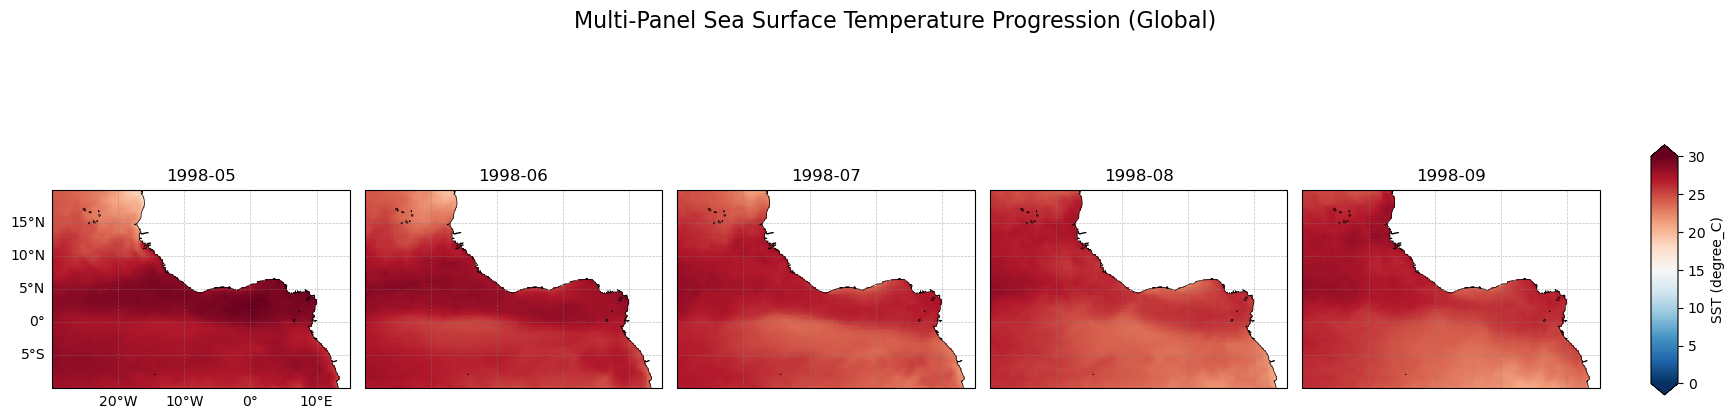

In [14]:
# Define the projection (PlateCarree is WGS84, good for global views)
map_proj = ccrs.PlateCarree(central_longitude=0) 

# Create the figure: 1 row, 5 columns
fig, axes = plt.subplots(
    nrows=1,
    ncols=N_PLOTS,
    figsize=(18, 5), # Total figure size (wide)
    subplot_kw={'projection': map_proj} # Apply the map projection to all subplots
)

# Determine global min/max SST for a consistent color scale across all panels
vmin = 0 #ds2['sst'].min().item()
vmax = 30 #ds2['sst'].max().item()

# --- 3. Iterate and Plot ---
for i, ax in enumerate(axes.flat):
    current_time = time_slices[i]
    sst_panel = ds_bigbox.sel(time=current_time)

    # Plot the data using pcolormesh
    plot = sst_panel.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(), # Data CRS is WGS84
        x='longitude',
        y='latitude',
        cmap = colormap, #cmap='coolwarm',
        vmin=vmin, # Use consistent limits
        vmax=vmax,
        add_colorbar=False # We will add a single colorbar later
    )
    
    # Add map features
    ax.coastlines(resolution='50m', color='black', linewidth=0.5)
    #ax.set_global() #this forces the plot to show the whole earth
    
    # Add title with the time stamp
    ax.set_title(current_time.dt.strftime('%Y-%m').item(), fontsize=12)
    
    # Optional: Add gridlines (only for the first panel to save space/cleanliness)
    if i == 0:
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
    else:
        # Hide axis labels for subsequent panels for a cleaner look
        gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        ax.set_ylabel('') # xarray often adds 'latitude', this removes it

# --- 4. Add a Single Colorbar and Final Touches ---

# Use the plot object from the last iteration to create a single colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5]) # [left, bottom, width, height]
cbar = fig.colorbar(
    plot,
    cax=cbar_ax,
    orientation='vertical',
    label=f'SST ({ds_bigbox.units})',
    extend='both' # Extends colorbar if data is outside vmin/vmax
)

# Adjust layout to prevent overlap and make room for the colorbar
plt.suptitle('Multi-Panel Sea Surface Temperature Progression (Global)', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust space for the main title and colorbar

plt.show()

/tmp/ipykernel_324/3025678943.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust space for the main title and colorbar


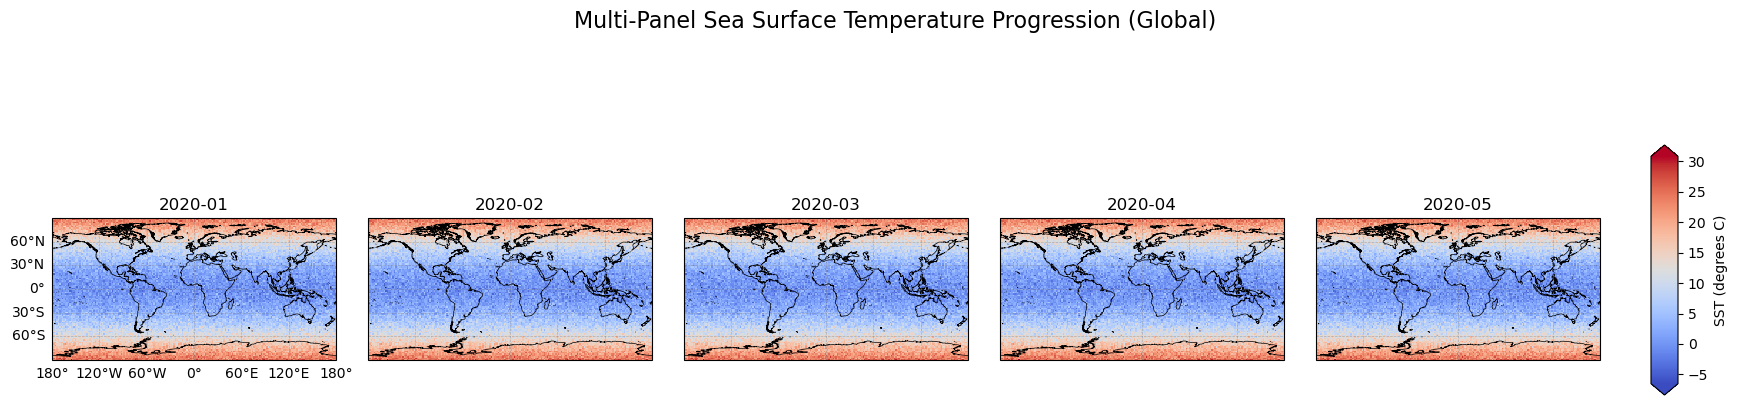

In [12]:
# --- 1. Simulate Data Loading and Preprocessing ---
# In a real scenario, you would open your dataset: ds = xr.open_dataset('your_sst_data.nc')
# We'll create a synthetic dataset that mimics your dimensions for demonstration.

#n_time = 12 # Use 12 months for 5 panels
#n_lat = 100
#n_lon = 200

# Create realistic coordinates and data
#time_coords = pd.date_range('2020-01-01', periods=n_time, freq='MS')
#lat = np.linspace(-89.88, 89.88, n_lat, dtype=np.float32)
#lon = np.linspace(0.125, 359.875, n_lon, dtype=np.float32)

# Create synthetic SST data (SST usually ranges from -2 to 32 C)
# Add some structure to make it look like a map (e.g., lower SST at high latitudes)
#sst_base = 25 - 25 * np.cos(np.deg2rad(lat[:, None])) + np.random.randn(n_lat, n_lon) * 2
#sst_data = np.tile(sst_base, (n_time, 1, 1))

#ds = xr.Dataset(
#    {'sst': (('time', 'latitude', 'longitude'), sst_data.astype(np.float32))},
#    coords={'time': time_coords, 'latitude': lat, 'longitude': lon}
#)
#ds['sst'].attrs['units'] = 'degrees C'
#ds['sst'].attrs['long_name'] = 'Sea Surface Temperature'







# --- 3. Iterate and Plot ---
for i, ax in enumerate(axes.flat):
    current_time = time_slices[i]
    sst_panel = ds_reindexed['sst'].sel(time=current_time)

    # Plot the data using pcolormesh
    plot = sst_panel.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(), # Data CRS is WGS84
        x='longitude',
        y='latitude',
        cmap='coolwarm',
        vmin=vmin, # Use consistent limits
        vmax=vmax,
        add_colorbar=False # We will add a single colorbar later
    )
    
    # Add map features
    ax.coastlines(resolution='50m', color='black', linewidth=0.5)
    ax.set_global()
    
    # Add title with the time stamp
    ax.set_title(current_time.dt.strftime('%Y-%m').item(), fontsize=12)
    
    # Optional: Add gridlines (only for the first panel to save space/cleanliness)
    if i == 0:
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
    else:
        # Hide axis labels for subsequent panels for a cleaner look
        gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        ax.set_ylabel('') # xarray often adds 'latitude', this removes it

# --- 4. Add a Single Colorbar and Final Touches ---

# Use the plot object from the last iteration to create a single colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5]) # [left, bottom, width, height]
cbar = fig.colorbar(
    plot,
    cax=cbar_ax,
    orientation='vertical',
    label=f'SST ({ds["sst"].units})',
    extend='both' # Extends colorbar if data is outside vmin/vmax
)

# Adjust layout to prevent overlap and make room for the colorbar
plt.suptitle('Multi-Panel Sea Surface Temperature Progression (Global)', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust space for the main title and colorbar

plt.show()